# HW02

dataset: https://www.kaggle.com/datasets/mpwolke/cusersmarildownloadsseniorcsv?resource=download

In [25]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly  

#from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

df = pd.read_csv("senior.csv", sep=';')

# Lookup

In [26]:
print("\nПервые 5 строк\n")
df.head()


Первые 5 строк



,edition,report_type,measure_name,state_name,rank,value,score,lower_CI,upper_CI,source
0,2022,2022 Senior,Able-bodied,Alaska,32.0,66.2,-0.09,69.5,62.9,AHR data
1,2022,2022 Senior,Able-bodied,Alabama,44.0,61.7,-1.48,62.7,60.7,AHR data
2,2022,2022 Senior,Able-bodied,United States,NaN,66.5,NaN,66.6,66.4,AHR data
3,2022,2022 Senior,Able-bodied,Arkansas,49.0,58.8,-2.00,60.2,57.4,AHR data
4,2022,2022 Senior,Able-bodied,Arizona,22.0,67.0,0.15,67.8,66.2,AHR data


In [ ]:
df.tail()

,edition,report_type,measure_name,state_name,rank,value,score,lower_CI,upper_CI,source
27296,2022,2022 Senior,Voter Participation (Presidential) - Ages 65+,Vermont,8.0,79.6,1.1,86.5,72.7,AHR data
27297,2022,2022 Senior,Voter Participation (Presidential) - Ages 65+,Washington,13.0,77.3,0.6,83.1,71.5,AHR data
27298,2022,2022 Senior,Voter Participation (Presidential) - Ages 65+,Wisconsin,4.0,82.4,1.7,88.5,76.3,AHR data
27299,2022,2022 Senior,Voter Participation (Presidential) - Ages 65+,West Virginia,46.0,68.0,-1.4,75.9,60.1,AHR data
27300,2022,2022 Senior,Voter Participation (Presidential) - Ages 65+,Wyoming,15.0,76.6,0.5,84.5,68.7,AHR data


In [28]:
df.shape

(27301, 10)

In [29]:
print("\nОбщая информация о датасете:")
df.info()

df.describe()


Общая информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 27301 entries, 0 to 27300
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edition       27301 non-null  int64  
 1   report_type   27301 non-null  str    
 2   measure_name  27301 non-null  str    
 3   state_name    27301 non-null  str    
 4   rank          12700 non-null  float64
 5   value         19520 non-null  float64
 6   score         4901 non-null   float64
 7   lower_CI      15577 non-null  float64
 8   upper_CI      15577 non-null  float64
 9   source        27301 non-null  str    
dtypes: float64(5), int64(1), str(4)
memory usage: 2.1 MB


,edition,rank,value,score,lower_CI,upper_CI
count,27301.0,12700.000000,19520.000000,4901.000000,15577.000000,15577.000000
mean,2022.0,25.206063,142.345264,-0.031124,95.999181,77.719680
std,0.0,14.484549,490.687792,0.896384,411.320000,330.975932
min,2022.0,1.000000,-2.000000,-2.000000,2.100000,0.600000
25%,2022.0,13.000000,9.600000,-0.643000,13.700000,8.100000
50%,2022.0,25.000000,24.900000,-0.020000,29.300000,19.700000
75%,2022.0,38.000000,58.800000,0.570000,62.100000,46.800000
max,2022.0,50.000000,11504.000000,2.000000,16857.000000,7515.000000


In [30]:
df.describe(include="str") # с object траблы

,report_type,measure_name,state_name,source
count,27301,27301,27301,27301
unique,1,511,52,1
top,2022 Senior,Disability,Wyoming,AHR data
freq,27301,104,526,27301


In [31]:
# например, посчитаем моду для measure_name
measure_name_mode = df['measure_name'].mode()[0] 
print(measure_name_mode)
#df['measure_name'] = df['measure_name'].fillna(measure_name_mode)

Disability


категориальные колонки в моем датасете не имеют пропусков, поэтому модой ничего не будет заполняться

In [32]:
# можем удалить столбцы edition report_type и source

df.drop(columns=["report_type", 'source', 'edition'], inplace=True)

In [33]:
df.isnull().sum()

measure_name        0
state_name          0
rank            14601
value            7781
score           22400
lower_CI        11724
upper_CI        11724
dtype: int64

# Gaps and Cleanup

In [34]:
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

df = df.drop_duplicates(ignore_index=True)

Количество полных дубликатов: 416


In [35]:
df = df.dropna(subset=['value']) # строка бесполезна без value
df['rank'] = df['rank'].fillna(0) # ранк от 1 до 50, заполним пропуски нулями, чтоб не повлиять никак
df['score'] = df['score'].fillna(0) # Z-score (значения от -2 до 2)


# можно было бы удалить строки, у к-х следующие столбцы пустые,
# но мы бы потеряли почти половину датасета, поэтому будем считать, что value без погрещности
df['lower_CI'] = df['lower_CI'].fillna(df['value'])
df['upper_CI'] = df['upper_CI'].fillna(df['value'])


In [36]:
stats = df.describe(include=['number'],percentiles=[.05, .25, .5, .75, .95])

mode_row = df.select_dtypes(include=['number']).mode().iloc[0:1]
mode_row.index = ['mode']


stats = pd.concat([stats, mode_row])
display(stats)



,rank,value,score,lower_CI,upper_CI
count,19155.000000,19155.000000,19155.000000,19155.000000,19155.000000
mean,16.512451,112.295096,-0.006967,120.001863,105.136827
std,16.762285,426.164416,0.445641,458.547576,403.152432
min,0.000000,-2.000000,-2.000000,-2.000000,-2.000000
5%,0.000000,0.619800,-0.790000,0.619800,0.615200
25%,0.000000,9.400000,0.000000,11.700000,7.000000
50%,12.000000,24.200000,0.000000,28.400000,19.300000
75%,31.000000,54.000000,0.000000,59.150000,49.700000
95%,47.000000,100.000000,0.700000,100.000000,100.000000
max,50.000000,11504.000000,2.000000,16857.000000,7515.000000


In [37]:
variance = df.select_dtypes(include=['number']).var()
skewness = df.select_dtypes(include=['number']).skew()
kurtosis = df.select_dtypes(include=['number']).kurt()


extra_stats = pd.DataFrame([variance, skewness, kurtosis], 
                           index=['variance', 'skewness', 'kurtosis'])
display(extra_stats)

,rank,value,score,lower_CI,upper_CI
variance,280.974198,181616.109861,0.198596,210265.879506,162531.883138
skewness,0.528112,6.710833,-0.166856,8.145767,6.171386
kurtosis,-1.169983,65.467760,7.809643,132.679953,45.266629


сделаем вывод о наиболее интересной колонке value 

большая дисперсия говорит о неоднородности данных

положительная ассиметрия значит, что у большинства штатов показатели низкие (хорошие), но есть «длинный хвост» из нескольких проблемных штатов

эксцесс сильно больше 3: в данных аномально много экстремальных значений

# Encoding


In [38]:
df_encoded = df.copy()

в моем датасете OHE неуместна, потому что категория имеет либо слишком много значений, либо 1 уникальное, в комментариях покажу как бы делал этот вид кодирования, если бы это имело смысл

In [39]:
#df_encoded = pd.get_dummies(df, columns=['source'])

label encoding плох тем, что порождает математическую зависимость, его не будем использовать

In [40]:
df_encoded.head()

,measure_name,state_name,rank,value,score,lower_CI,upper_CI
0,Able-bodied,Alaska,32.0,66.2,-0.09,69.5,62.9
1,Able-bodied,Alabama,44.0,61.7,-1.48,62.7,60.7
2,Able-bodied,United States,0.0,66.5,0.00,66.6,66.4
3,Able-bodied,Arkansas,49.0,58.8,-2.00,60.2,57.4
4,Able-bodied,Arizona,22.0,67.0,0.15,67.8,66.2


In [41]:
#target encoding

# так как value имеет сильный разброс и отвечает то за проценты,
#  то за денежный эквивалент, то за количество,
# кодировать по нему не валидно

# в отличие от value, score везде имеет одинаковый смысл 

encoder = ce.TargetEncoder(cols=['state_name'])
df_encoded['state_score_target'] = encoder.fit_transform(df_encoded['state_name'],df_encoded['score'] )


In [42]:
display(df_encoded[['state_name', 'state_score_target']].drop_duplicates().head())


,state_name,state_score_target
0,Alaska,-0.006066
1,Alabama,-0.034524
2,United States,0.000000
3,Arkansas,-0.016880
4,Arizona,0.012530


measure_name имеет 502 уникальных значения, но многие из них имеют одинаковую часть + просто уточнения. можно разбить на группы

In [43]:
df_encoded['measure_group'] = df_encoded['measure_name'].str.split(' - ').str[0]

print(f"Уникальных групп: {df_encoded['measure_group'].nunique()}")

Уникальных групп: 82


In [44]:
hash_enc = ce.HashingEncoder(cols=['measure_group'], n_components=7)

df_encoded = hash_enc.fit_transform(df_encoded)
display(df_encoded.filter(like='col_'))



,col_0,col_1,col_2,col_3,col_4,col_5,col_6
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...
26880,0,0,0,0,1,0,0
26881,0,0,0,0,1,0,0
26882,0,0,0,0,1,0,0
26883,0,0,0,0,1,0,0


Создаем новые фичи

In [45]:
max_rank = df_encoded['rank'].max()
df_encoded['rank_inverted'] = max_rank - df_encoded['rank'] + 1  # 50->1, 1->50
df_encoded['value_x_rank_inv'] = df_encoded['value'] * df_encoded['rank_inverted']

df_encoded['uncertainty_ratio'] = (df_encoded['upper_CI'] - df_encoded['lower_CI']) / (df_encoded['value'] + 1e-5)

In [46]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 19155 entries, 0 to 26884
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   col_0               19155 non-null  int64  
 1   col_1               19155 non-null  int64  
 2   col_2               19155 non-null  int64  
 3   col_3               19155 non-null  int64  
 4   col_4               19155 non-null  int64  
 5   col_5               19155 non-null  int64  
 6   col_6               19155 non-null  int64  
 7   measure_name        19155 non-null  str    
 8   state_name          19155 non-null  str    
 9   rank                19155 non-null  float64
 10  value               19155 non-null  float64
 11  score               19155 non-null  float64
 12  lower_CI            19155 non-null  float64
 13  upper_CI            19155 non-null  float64
 14  state_score_target  19155 non-null  float64
 15  rank_inverted       19155 non-null  float64
 16  value_x_rank_inv    

# Visualisation

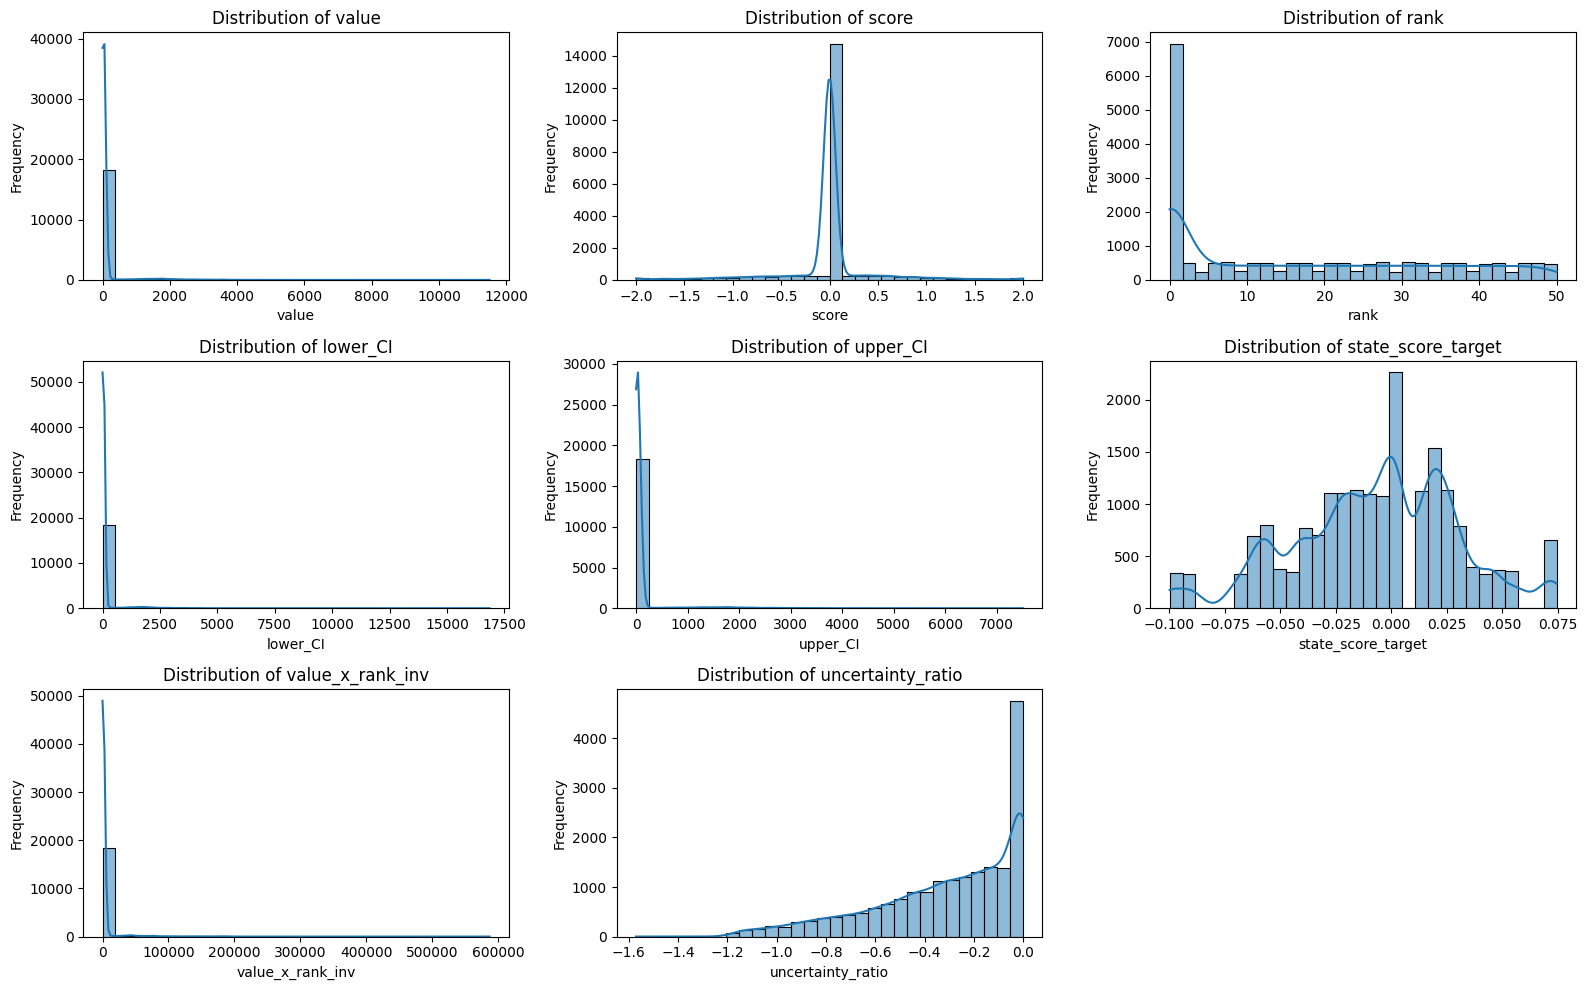

In [47]:
# 1. Распределения: гистограммы + KDE 
num_cols = ['value', 'score', 'rank', 'lower_CI', 'upper_CI', 
            'state_score_target', 'value_x_rank_inv', 'uncertainty_ratio']

plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

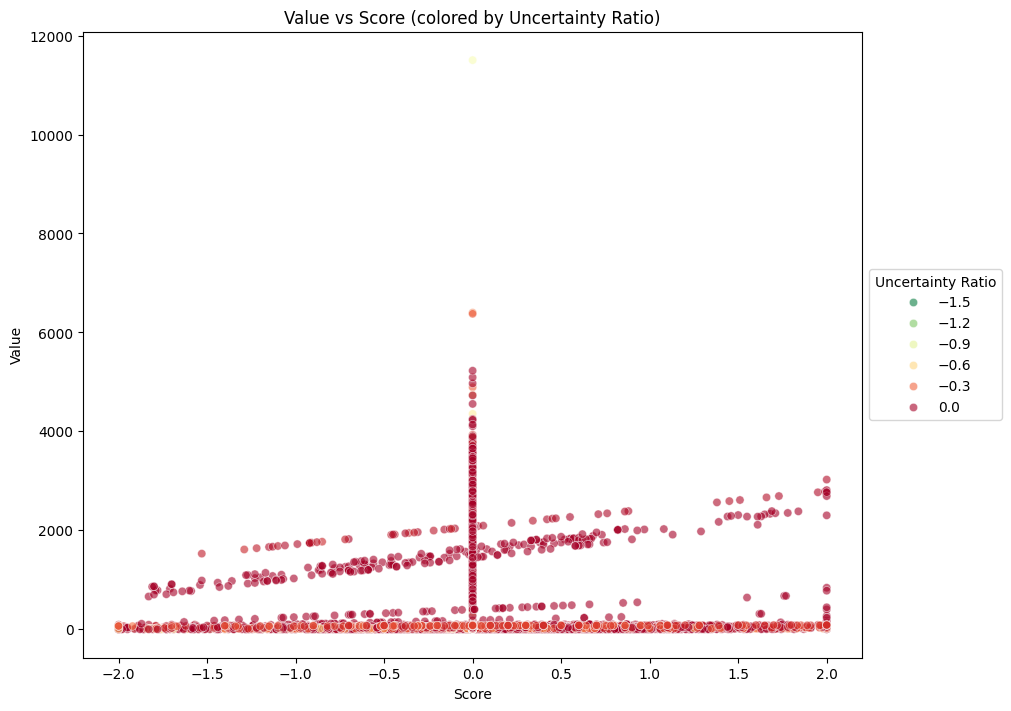

In [ ]:
# 2. Scatter plot — зависимости между числами (seaborn)
plt.figure(figsize=(10, 7), constrained_layout=True)

scatter = sns.scatterplot(
    data=df_encoded,
    x='score',
    y='value',
    hue='uncertainty_ratio',
    palette='RdYlGn_r',
    alpha=0.6,

)

plt.title('Value vs Score (colored by Uncertainty Ratio)')
plt.xlabel('Score')
plt.ylabel('Value')

plt.legend(title='Uncertainty Ratio', loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)

plt.show()

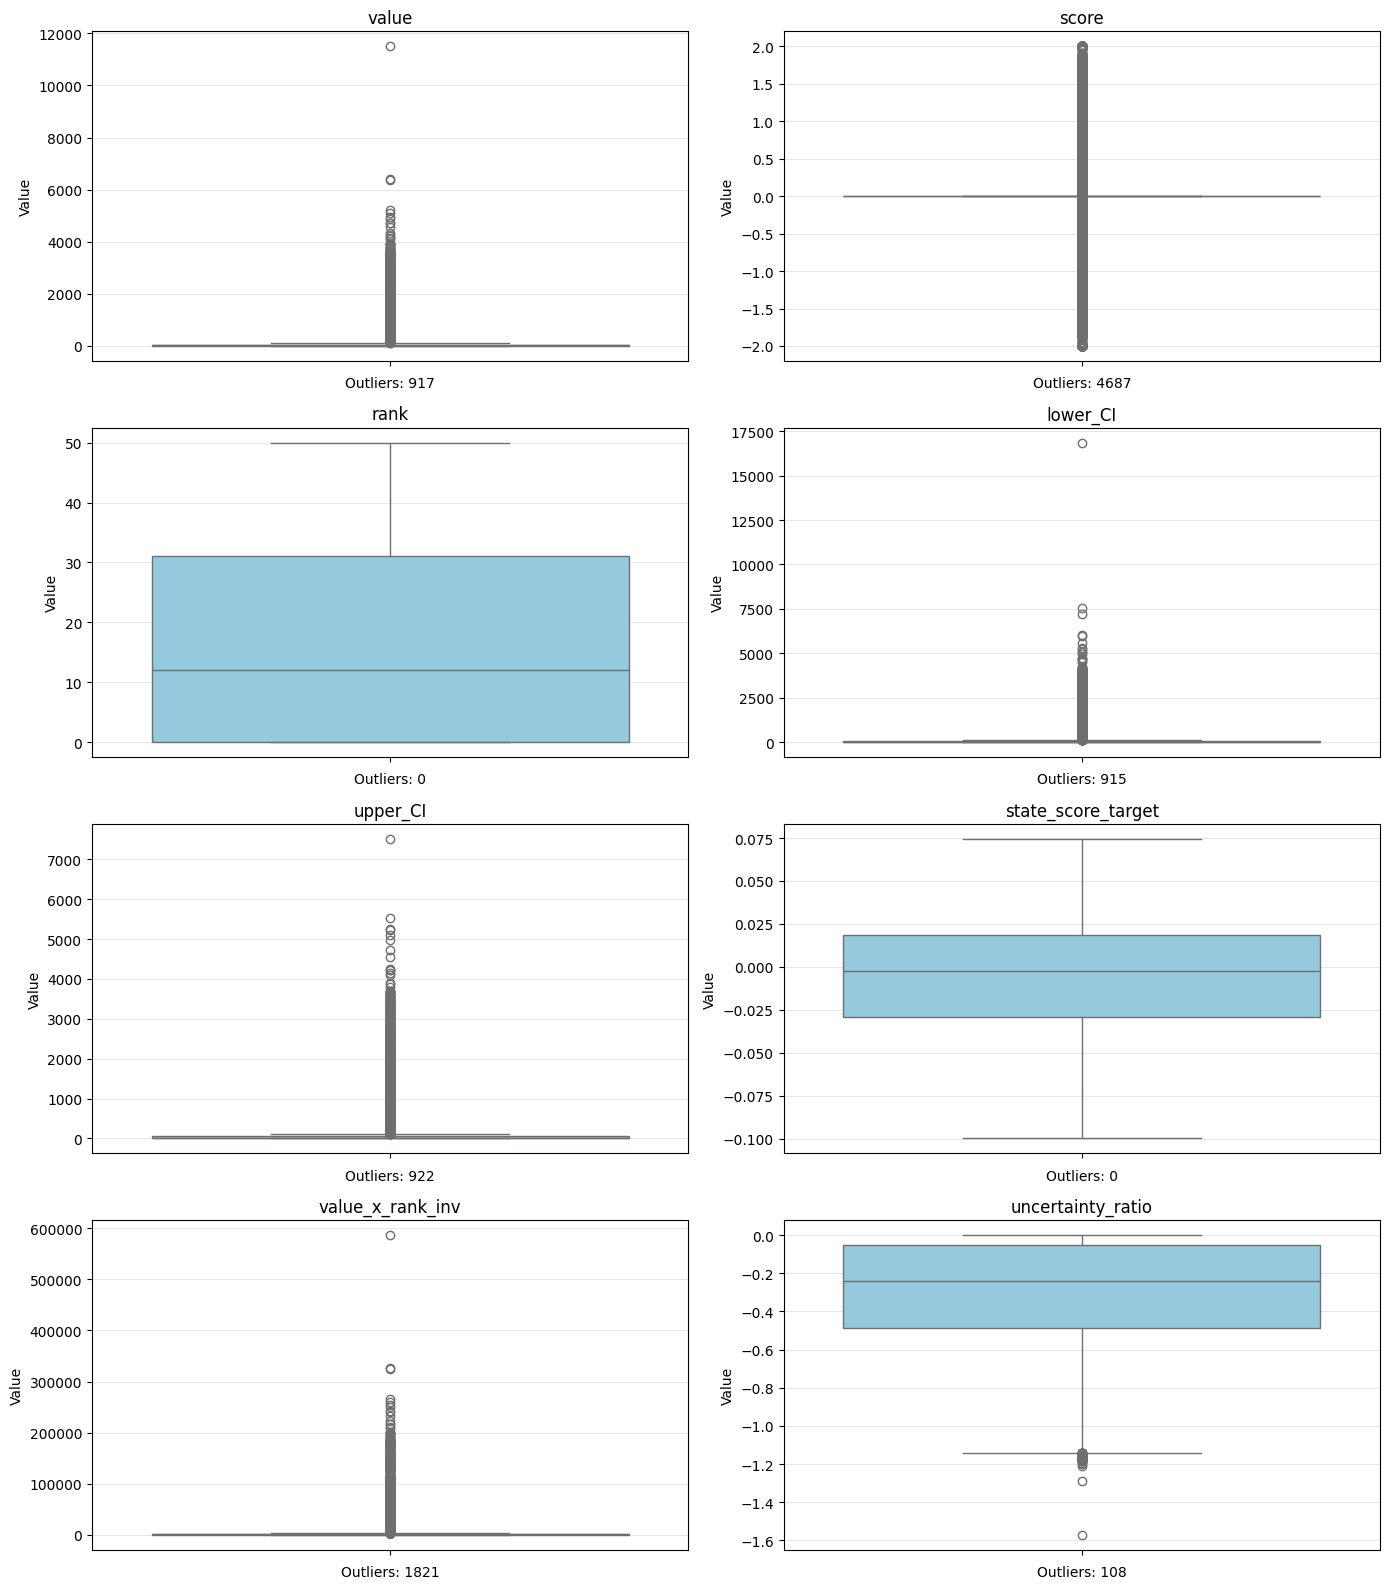


СТАТИСТИКА ВЫБРОСОВ (по правилу 1.5×IQR):
value               :  917 выбросов ( 4.79%)
score               : 4687 выбросов (24.47%)
rank                :    0 выбросов ( 0.00%)
lower_CI            :  915 выбросов ( 4.78%)
upper_CI            :  922 выбросов ( 4.81%)
state_score_target  :    0 выбросов ( 0.00%)
value_x_rank_inv    : 1821 выбросов ( 9.51%)
uncertainty_ratio   :  108 выбросов ( 0.56%)


In [49]:
# 3. Box plot — поиск выбросов (seaborn)

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    

    sns.boxplot(y=df_encoded[col], color='skyblue', showfliers=True)
    
    plt.title(f'{col}')
    plt.ylabel('Value')
    plt.grid(axis='y', alpha=0.3)
    

    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_encoded[col] < Q1 - 1.5 * IQR) | 
                (df_encoded[col] > Q3 + 1.5 * IQR)).sum()
    plt.xlabel(f'Outliers: {outliers}')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СТАТИСТИКА ВЫБРОСОВ (по правилу 1.5×IQR):")
print("="*60)
for col in num_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df_encoded[col] < lower_bound) | 
                (df_encoded[col] > upper_bound)).sum()
    pct = outliers / len(df_encoded) * 100
    print(f"{col:20s}: {outliers:4d} выбросов ({pct:5.2f}%)")
print("="*60)

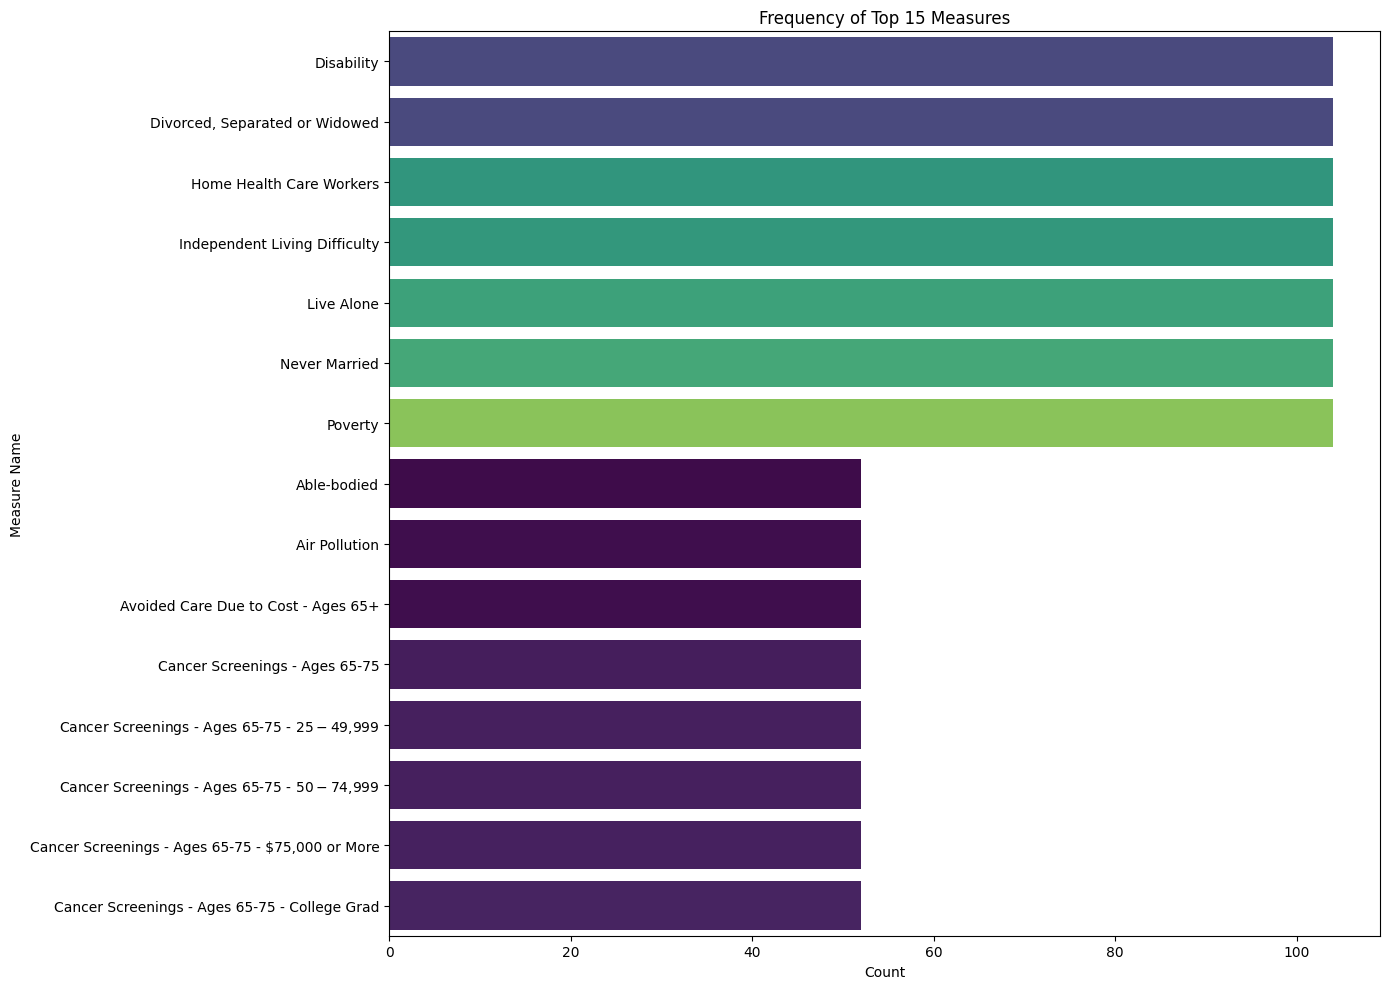

In [50]:
# 4. Bar/Count plot для категорий
plt.figure(figsize=(14, 10))

top_measures = df_encoded['measure_name'].value_counts().head(15).index

sns.countplot(
    data=df_encoded,
    y='measure_name',
    order=top_measures,
    hue='measure_name',  
    palette='viridis',
    legend=False 
)

plt.title('Frequency of Top 15 Measures')
plt.xlabel('Count')
plt.ylabel('Measure Name')
plt.tight_layout()
plt.show()

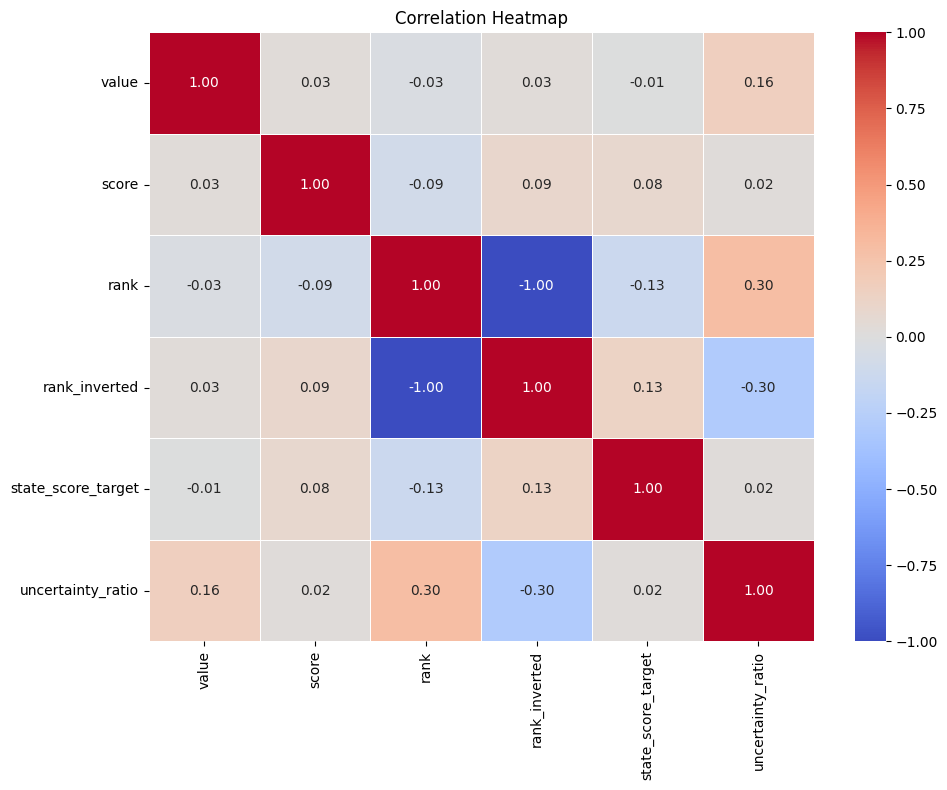


ВЫВОД ПО КОРРЕЛЯЦИЯМ:
Сильные корреляции (> 0.5 или < -0.5):
• rank ↔ rank_inverted: -1.00 (обратная)


In [51]:
# 5. Heatmap корреляций
corr_cols = ['value', 'score', 'rank', 'rank_inverted', 
             'state_score_target', 'uncertainty_ratio']
corr = df_encoded[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("ВЫВОД ПО КОРРЕЛЯЦИЯМ:")
print("="*60)

strong_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            strong_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if strong_corr:
    print("Сильные корреляции (> 0.5 или < -0.5):")
    for col1, col2, val in strong_corr:
        direction = "прямая" if val > 0 else "обратная"
        print(f"• {col1} ↔ {col2}: {val:.2f} ({direction})")
else:
    print("• Нет сильных корреляций (> 0.5)")

print("="*60)

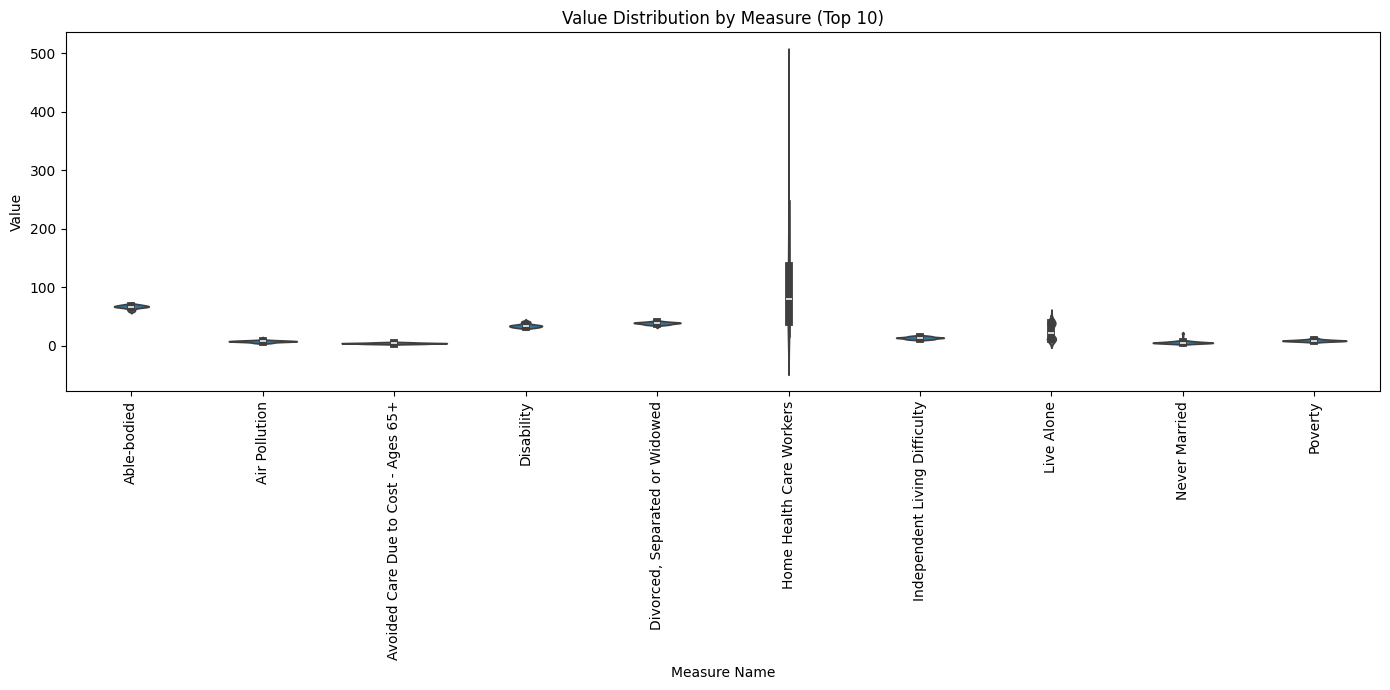

In [52]:
# 6. Violinplot
plt.figure(figsize=(14, 7))

top_measures_violin = df_encoded['measure_name'].value_counts().head(10).index
df_violin = df_encoded[df_encoded['measure_name'].isin(top_measures_violin)]

sns.violinplot(
    data=df_violin,
    x='measure_name',
    y='value'
)

plt.xticks(rotation=90)
plt.title('Value Distribution by Measure (Top 10)')
plt.xlabel('Measure Name')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

# 7. Интерактивный график Plotly с hover_data
import plotly.express as px

fig = px.scatter(
    df_encoded,
    x='score',
    y='value',
    color='state_name',
    hover_data=['measure_name', 'rank', 'lower_CI', 'upper_CI', 'uncertainty_ratio'],
    title='Interactive Relationship: Score vs Value (by State)',
    labels={'score': 'Score', 'value': 'Value'},
    height=700,
    width=1200
)

fig.update_layout(
    hovermode='closest',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

# Markdown

## Что я понял про датасет:

- Датасет содержит ~27k строк, после очистки осталось ~19k наблюдений. Произошла значительная потеря из-за пропусков.
- Основная числовая переменная — value, но она измеряется в разных величинах (проценты, деньги, количество).
- В датасете присутствуют дубликаты (около 400 строк).
Категориальные признаки:
measure_name — очень высококардинальный (~500 значений).
- В числовых признаках много пропусков: score заполнен менее чем наполовину. rank и CI тоже частично отсутствуют.
- Распределение value: сильно правосторонне скошено (skewness ≫ 0), имеет тяжёлые хвосты (высокий kurtosis), что говорит о выбросах.
score выглядит более стабильной и нормированной метрикой (примерно от -2 до 2).
- Есть явная неоднородность данных: разные measure_name описывают разные явления.
- Корреляции между признаками в целом слабые -- линейной зависимости мало.

- В целом датасет по итогу оказался плохим из-за вариативности признаков, большого процента пропусков.

## Гипотезы/наблюдения

- measure_name сильно влияет на value
- Выбросы в value обусловлены не шумом, а природой данных
- score лучше подходит как целевая переменная, чем value так как нормирован и сопоставим между наблюдениями.


## Что бы делал дальше

Пытался бы предказать score.

## Какие подсказки брал у ИИ


Советовался по кодированию с ИИ, что выбрать и какие его виды подходят в определенных ситуациях. Также в визуализации спрашивал как отобразить лучше статистику выбросов